In [7]:
import requests
import pandas as pd
from tqdm import tqdm 
import time
import pars
import numpy as np
import matplotlib.pyplot as plt

In [6]:
asset_code = 'SBER'    
option_data_df = pars.collect_option_data(asset_code)

Сбор данных по опционам: 100%|███████████████████████████████████████████████████| 842/842 [06:47<00:00,  2.07опцион/s]


In [7]:
output_file = f"{asset_code}_options_data.csv"
option_data_df.to_csv(output_file, index=False)

In [8]:
option_data_df

,secid,asset_code,asset_type,futures_code,expiration_date,series_type,strike,option_type,delta,gamma,...,days_until_expiring,underlying_price,volatility,underlying_asset,underlying_type,theorprice,fee,expiring_date,lastprice,settleprice
0,SR260CC5A,SBER,share,None,2025-03-05,W,260.0,call,0.998562,0.000256,...,2,309.63,79.97213,SBER,share,49.637619,0.05,2025-03-05,309.63,309.63
1,SR260CO5A,SBER,share,None,2025-03-05,W,260.0,put,-0.001438,0.000256,...,2,309.63,79.97213,SBER,share,0.007619,0.03,2025-03-05,309.63,309.63
2,SR270CC5A,SBER,share,None,2025-03-05,W,270.0,call,0.998041,0.000420,...,2,309.63,64.67436,SBER,share,39.638575,0.05,2025-03-05,309.63,309.63
3,SR270CO5A,SBER,share,None,2025-03-05,W,270.0,put,-0.001959,0.000420,...,2,309.63,64.67436,SBER,share,0.008575,0.03,2025-03-05,309.63,309.63
4,SR280CC5A,SBER,share,None,2025-03-05,W,280.0,call,0.996560,0.000892,...,2,309.63,50.63194,SBER,share,29.642331,0.05,2025-03-05,309.63,309.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,SR395CO9,SBER,share,None,2029-03-21,Q,395.0,put,-0.546500,0.002166,...,1479,309.63,29.34723,SBER,share,131.143361,0.06,2029-03-21,309.63,309.63
838,SR400CC9,SBER,share,None,2029-03-21,Q,400.0,call,0.444811,0.002162,...,1479,309.63,29.32046,SBER,share,44.525895,0.06,2029-03-21,309.63,309.63
839,SR400CO9,SBER,share,None,2029-03-21,Q,400.0,put,-0.555189,0.002162,...,1479,309.63,29.32046,SBER,share,134.895895,0.06,2029-03-21,309.63,309.63
840,SR405CC9,SBER,share,None,2029-03-21,Q,405.0,call,0.436259,0.002157,...,1479,309.63,29.29582,SBER,share,43.316440,0.06,2029-03-21,309.63,309.63


# Описание выгруженного датафрейма

Датафрейм содержит информацию об опционах на актив (например, акции Сбербанка — `SBER`). Каждая строка соответствует одному опциону, а столбцы содержат различные характеристики опциона. Ниже приведено подробное описание столбцов.

---

## Столбцы датафрейма

### 1. **`secid`** (`str`)
- **Описание**: Уникальный идентификатор опциона.
- **Пример**: `"SR260CC5A"`.

### 2. **`asset_code`** (`str`)
- **Описание**: Код базового актива, на который выпущен опцион.
- **Пример**: `"SBER"`.

### 3. **`asset_type`** (`str`)
- **Описание**: Тип базового актива (например, акция, фьючерс).
- **Пример**: `"share"`.

### 4. **`futures_code`** (`str` или `None`)
- **Описание**: Код связанного фьючерса (если опцион основан на фьючерсе).
- **Пример**: `None` (если опцион основан на акции).

### 5. **`expiration_date`** (`str`)
- **Описание**: Дата экспирации опциона в формате `YYYY-MM-DD`.
- **Пример**: `"2025-03-05"`.

### 6. **`series_type`** (`str`)
- **Описание**: Тип серии опциона (например, недельная, месячная).
- **Пример**: `"W"` (недельная серия).

### 7. **`strike`** (`float`)
- **Описание**: Страйк-цена опциона (цена исполнения).
- **Пример**: `260.0`.

### 8. **`option_type`** (`str`)
- **Описание**: Тип опциона: `"call"` (колл) или `"put"` (пут).
- **Пример**: `"call"`.

### 9. **`delta`** (`float`)
- **Описание**: Дельта опциона — чувствительность цены опциона к изменению цены базового актива.
- **Пример**: `0.992773`.

### 10. **`gamma`** (`float`)
- **Описание**: Гамма опциона — скорость изменения дельты.
- **Пример**: `0.000893`.

### 11. **`vega`** (`float`)
- **Описание**: Вега опциона — чувствительность цены опциона к изменению волатильности.
- **Пример**: `0.005626`.

### 12. **`theta`** (`float`)
- **Описание**: Тета опциона — чувствительность цены опциона к изменению времени до экспирации.
- **Пример**: `-0.074993`.

### 13. **`rho`** (`float`)
- **Описание**: Ро опциона — чувствительность цены опциона к изменению процентной ставки.
- **Пример**: `0.021181`.

### 14. **`days_until_expiring`** (`int`)
- **Описание**: Количество дней до экспирации опциона.
- **Пример**: `3`.

### 15. **`underlying_price`** (`float`)
- **Описание**: Текущая цена базового актива.
- **Пример**: `309.63`.

### 16. **`volatility`** (`float`)
- **Описание**: Волатильность опциона (в процентах).
- **Пример**: `79.97213`.

### 17. **`underlying_asset`** (`str`)
- **Описание**: Название базового актива.
- **Пример**: `"SBER"`.

### 18. **`underlying_type`** (`str`)
- **Описание**: Тип базового актива (например, акция).
- **Пример**: `"share"`.

### 19. **`theorprice`** (`float`)
- **Описание**: Теоретическая цена опциона, рассчитанная моделью (например, Блэка-Шоулза).
- **Пример**: `49.684348`.

### 20. **`fee`** (`float`)
- **Описание**: Комиссия за опцион.
- **Пример**: `0.05`.

### 21. **`lastprice`** (`float`)
- **Описание**: Последняя цена опциона.
- **Пример**: `309.63`.

### 22. **`settleprice`** (`float`)
- **Описание**: Расчетная цена опциона.
- **Пример**: `309.63`.

---

## Пример строки датафрейма

```plaintext
secid          SR260CC5A
asset_code     SBER
asset_type     share
futures_code   None
expiration_date 2025-03-05
series_type    W
strike         260.0
option_type    call
delta          0.992773
gamma          0.000893
vega           0.005626
theta          -0.074993
rho            0.021181
days_until_expiring 3
underlying_price 309.63
volatility     79.97213
underlying_asset SBER
underlying_type share
theorprice     49.684348
fee            0.05
lastprice      309.63
settleprice    309.63

# Поверхность

In [3]:
option_data_df = pd.read_csv('SBER_options_data.csv')

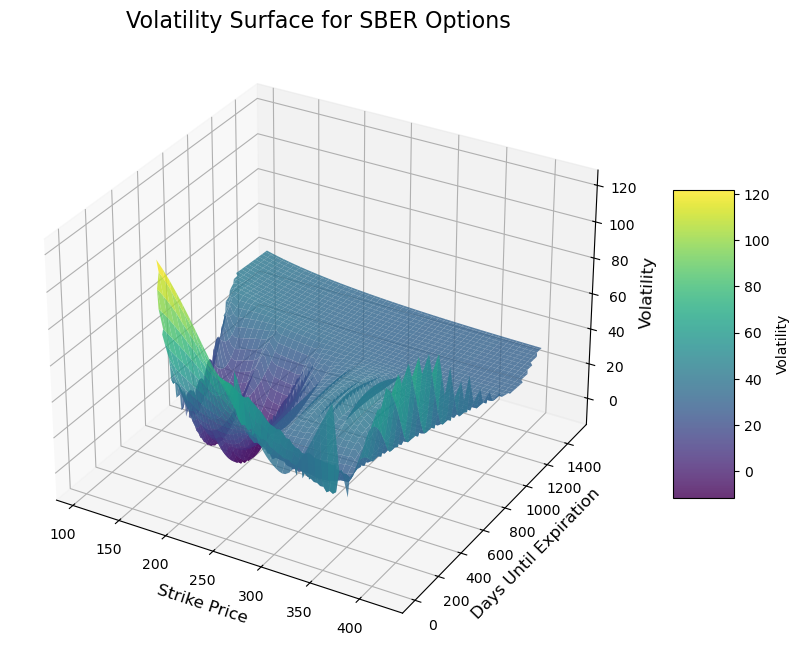

In [9]:
strikes = option_data_df['strike'].values
days_until_expiring = option_data_df['days_until_expiring'].values
volatility = option_data_df['volatility'].values

# Создаем сетку для построения поверхности
strike_grid, days_grid = np.meshgrid(
    np.linspace(min(strikes), max(strikes), 100),  # Страйки
    np.linspace(min(days_until_expiring), max(days_until_expiring), 100)  # Время до экспирации
)

# Интерполяция волатильности на сетке
from scipy.interpolate import griddata
volatility_grid = griddata(
    (strikes, days_until_expiring), 
    volatility,  
    (strike_grid, days_grid), 
    method='cubic'  
)

# Построение поверхности
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Рисуем поверхность
surf = ax.plot_surface(
    strike_grid, days_grid, volatility_grid,
    cmap='viridis',
    edgecolor='none',
    alpha=0.8
)


ax.set_xlabel('Strike Price', fontsize=12)
ax.set_ylabel('Days Until Expiration', fontsize=12)
ax.set_zlabel('Volatility', fontsize=12)
ax.set_title('Volatility Surface for SBER Options', fontsize=16)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Volatility')

plt.show()